In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

np.random.seed(42)

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [ ]:
n = 50000

df = pd.DataFrame({

    "transaction_id": range(1, n + 1),

    "amount": np.round(
        np.random.lognormal(
            mean=7,
            sigma=1,
            size=n
        ),
        2
    ),

    "device": np.random.choice(
        ["Mobile", "Desktop", "Tablet"],
        size=n,
        p=[0.60, 0.30, 0.10]
    ),

    "payment_method": np.random.choice(
        ["UPI", "Card", "NetBanking", "Wallet"],
        size=n,
        p=[0.45, 0.30, 0.15, 0.10]
    ),

    "hour": np.random.randint(
        0,
        24,
        size=n
    ),

    "is_returning_user": np.random.choice(
        [0, 1],
        size=n,
        p=[0.65, 0.35]
    ),

    "checkout_started": np.random.choice(
        [0, 1],
        size=n,
        p=[0.08, 0.92]
    ),

    "location": np.random.choice(
        ["Metro", "Urban", "Semi-Urban", "Rural"],
        size=n,
        p=[0.35, 0.35, 0.20, 0.10]
    )
})

print("Dataset created successfully! ✅")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Dataset created successfully! ✅
Rows: 50000
Columns: 8


,transaction_id,amount,device,payment_method,hour,is_returning_user,checkout_started,location
0,1,1802.11,Mobile,NetBanking,7,1,1,Urban
1,2,955.02,Mobile,Card,22,1,1,Metro
2,3,2095.80,Tablet,Card,17,0,1,Metro
3,4,5029.27,Tablet,UPI,0,0,1,Metro
4,5,867.70,Mobile,NetBanking,17,0,1,Urban


In [ ]:
probability = np.full(n, 0.78)

# Device effect
probability -= np.where(
    df["device"] == "Mobile",
    0.05,
    0
)

probability += np.where(
    df["device"] == "Desktop",
    0.03,
    0
)

# Payment method effect
probability += np.where(
    df["payment_method"] == "UPI",
    0.04,
    0
)

probability -= np.where(
    df["payment_method"] == "NetBanking",
    0.04,
    0
)

# Returning users
probability += np.where(
    df["is_returning_user"] == 1,
    0.05,
    0
)

# Checkout started
probability -= np.where(
    df["checkout_started"] == 0,
    0.45,
    0
)

# Very late night transactions
probability -= np.where(
    df["hour"].isin([1, 2, 3, 4, 5]),
    0.04,
    0
)

# Large transactions
probability -= np.where(
    df["amount"] > 50000,
    0.06,
    0
)

# Keep probability between 5% and 95%
probability = np.clip(
    probability,
    0.05,
    0.95
)

# Generate target
df["payment_success"] = (
    np.random.random(n) < probability
).astype(int)

print("Target created! ✅")

df.head()

Target created! ✅


,transaction_id,amount,device,payment_method,hour,is_returning_user,checkout_started,location,payment_success
0,1,1802.11,Mobile,NetBanking,7,1,1,Urban,1
1,2,955.02,Mobile,Card,22,1,1,Metro,1
2,3,2095.80,Tablet,Card,17,0,1,Metro,0
3,4,5029.27,Tablet,UPI,0,0,1,Metro,0
4,5,867.70,Mobile,NetBanking,17,0,1,Urban,1


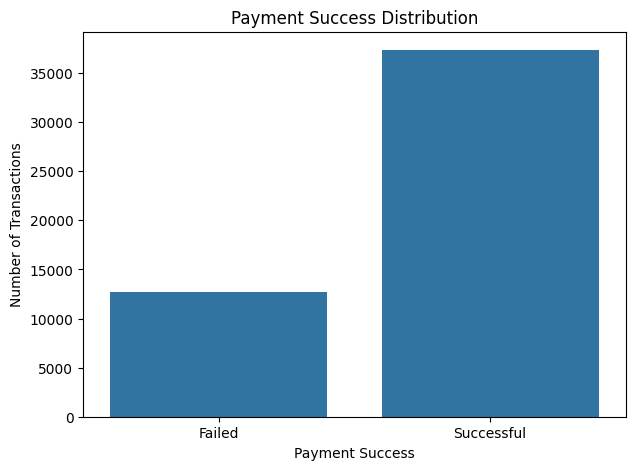

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="payment_success",
    data=df
)

plt.title("Payment Success Distribution")
plt.xlabel("Payment Success")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Failed", "Successful"]
)

plt.show()

In [ ]:
df.to_csv(
    "growgen_raw_commerce_data.csv",
    index=False
)

print("Raw dataset saved successfully! ✅")

Raw dataset saved successfully! ✅


In [ ]:
from google.colab import files

files.download(
    "growgen_raw_commerce_data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X = df.drop(
    columns=[
        "transaction_id",
        "payment_success"
    ]
)

y = df["payment_success"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['amount', 'device', 'payment_method', 'hour', 'is_returning_user', 'checkout_started', 'location']

Target:
payment_success


In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['amount', 'hour', 'is_returning_user', 'checkout_started']

Categorical features:
['device', 'payment_method', 'location']


In [ ]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

print("Preprocessing pipeline ready! ✅")

Preprocessing pipeline ready! ✅


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 7)
Testing data: (10000, 7)


In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        random_forest
    )
])

print("Random Forest model created! 🌲")

Random Forest model created! 🌲


In [ ]:
print("Training GROWGEN AI model...")

model.fit(
    X_train,
    y_train
)

print("Model training completed! ✅")

Training GROWGEN AI model...
Model training completed! ✅


In [ ]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated! ✅")

Predictions generated! ✅


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("================================")
print("      GROWGEN AI RESULTS")
print("================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

      GROWGEN AI RESULTS
Accuracy  : 0.6976
Precision : 0.7972
Recall    : 0.7981
F1 Score  : 0.7976
ROC-AUC   : 0.6405


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Payment Failed",
            "Payment Successful"
        ]
    )
)

                    precision    recall  f1-score   support

    Payment Failed       0.40      0.40      0.40      2532
Payment Successful       0.80      0.80      0.80      7468

          accuracy                           0.70     10000
         macro avg       0.60      0.60      0.60     10000
      weighted avg       0.70      0.70      0.70     10000



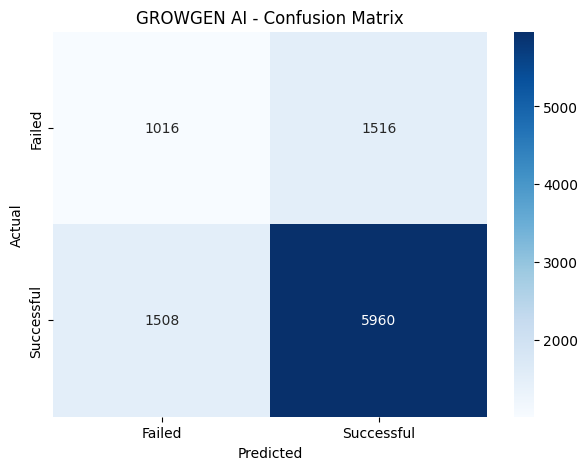

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Failed",
        "Successful"
    ],
    yticklabels=[
        "Failed",
        "Successful"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "GROWGEN AI - Confusion Matrix"
)

plt.show()

In [1]:
# ============================================
# GROWGEN AI - MODEL TRAINING
# Payment Success Prediction
# ============================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import joblib

np.random.seed(42)


# ============================================
# 2. CREATE SYNTHETIC COMMERCE DATASET
# ============================================

n = 50000

df = pd.DataFrame({

    "amount": np.round(
        np.random.lognormal(
            mean=7,
            sigma=1,
            size=n
        ),
        2
    ),

    "device": np.random.choice(
        ["Mobile", "Desktop", "Tablet"],
        size=n,
        p=[0.60, 0.30, 0.10]
    ),

    "payment_method": np.random.choice(
        ["UPI", "Card", "NetBanking", "Wallet"],
        size=n,
        p=[0.45, 0.30, 0.15, 0.10]
    ),

    "hour": np.random.randint(
        0,
        24,
        size=n
    ),

    "is_returning_user": np.random.choice(
        [0, 1],
        size=n,
        p=[0.65, 0.35]
    ),

    "checkout_started": np.random.choice(
        [0, 1],
        size=n,
        p=[0.08, 0.92]
    ),

    "location": np.random.choice(
        ["Metro", "Urban", "Semi-Urban", "Rural"],
        size=n,
        p=[0.35, 0.35, 0.20, 0.10]
    )
})


# ============================================
# 3. CREATE TARGET VARIABLE
# ============================================

# Base probability of payment success
probability = np.full(n, 0.78)

# Device effect
probability -= np.where(
    df["device"] == "Mobile",
    0.05,
    0
)

probability += np.where(
    df["device"] == "Desktop",
    0.03,
    0
)

# Payment method effect
probability += np.where(
    df["payment_method"] == "UPI",
    0.04,
    0
)

probability -= np.where(
    df["payment_method"] == "NetBanking",
    0.04,
    0
)

# Returning users
probability += np.where(
    df["is_returning_user"] == 1,
    0.05,
    0
)

# Checkout must be started
probability -= np.where(
    df["checkout_started"] == 0,
    0.45,
    0
)

# Late-night transactions
probability -= np.where(
    df["hour"].isin([1, 2, 3, 4, 5]),
    0.04,
    0
)

# Large transactions
probability -= np.where(
    df["amount"] > 50000,
    0.06,
    0
)

# Keep probability within reasonable range
probability = np.clip(
    probability,
    0.05,
    0.95
)

# Generate target
df["payment_success"] = (
    np.random.random(n) < probability
).astype(int)


# ============================================
# 4. PREPARE FEATURES AND TARGET
# ============================================

X = df.drop(
    columns=["payment_success"]
)

y = df["payment_success"]


# ============================================
# 5. IDENTIFY FEATURE TYPES
# ============================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()


# ============================================
# 6. PREPROCESSING
# ============================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([

    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),

    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


# ============================================
# 7. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================
# 8. CREATE RANDOM FOREST MODEL
# ============================================

rf = RandomForestClassifier(

    n_estimators=200,

    max_depth=12,

    min_samples_split=5,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1
)


# ============================================
# 9. COMPLETE ML PIPELINE
# ============================================

model = Pipeline([

    (
        "preprocessing",
        preprocessor
    ),

    (
        "random_forest",
        rf
    )
])


# ============================================
# 10. TRAIN MODEL
# ============================================

print("\nTraining GROWGEN AI model...")

model.fit(
    X_train,
    y_train
)

print("Training completed successfully!")


# ============================================
# 11. PREDICTION
# ============================================

y_pred = model.predict(
    X_test
)

y_probability = model.predict_proba(
    X_test
)[:, 1]


# ============================================
# 12. MODEL EVALUATION
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)


print("\n================================")
print("       GROWGEN AI RESULTS")
print("================================")

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)

print(
    f"ROC-AUC   : {roc_auc:.4f}"
)


# ============================================
# 13. CLASSIFICATION REPORT
# ============================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Payment Failed",
            "Payment Successful"
        ]
    )
)


# ============================================
# 14. SAVE TRAINED MODEL
# ============================================

joblib.dump(
    model,
    "growgen_ai_model.pkl"
)

print(
    "\nModel saved as: growgen_ai_model.pkl"
)

Training samples: 40000
Testing samples: 10000

Training GROWGEN AI model...
Training completed successfully!

       GROWGEN AI RESULTS
Accuracy  : 0.6976
Precision : 0.7972
Recall    : 0.7981
F1 Score  : 0.7976
ROC-AUC   : 0.6407

Classification Report:

                    precision    recall  f1-score   support

    Payment Failed       0.40      0.40      0.40      2532
Payment Successful       0.80      0.80      0.80      7468

          accuracy                           0.70     10000
         macro avg       0.60      0.60      0.60     10000
      weighted avg       0.70      0.70      0.70     10000


Model saved as: growgen_ai_model.pkl


In [2]:
# ============================================
# TEST A NEW TRANSACTION
# ============================================

new_transaction = pd.DataFrame([{

    "amount": 2499,

    "device": "Mobile",

    "payment_method": "UPI",

    "hour": 21,

    "is_returning_user": 1,

    "checkout_started": 1,

    "location": "Urban"
}])


# Prediction
prediction = model.predict(
    new_transaction
)[0]


# Probability
success_probability = model.predict_proba(
    new_transaction
)[0][1]


print("================================")
print("       GROWGEN AI")
print("================================")

print(
    f"Payment Success Probability: "
    f"{success_probability * 100:.2f}%"
)


if prediction == 1:

    print(
        "Prediction: Payment likely to succeed"
    )

else:

    print(
        "Prediction: Payment may fail"
    )

       GROWGEN AI
Payment Success Probability: 66.28%
Prediction: Payment likely to succeed
